In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np 

from forecaster import plot_dynamic, multi_model_forecast, acf_chacf

In [33]:
df = pd.read_excel('example.xlsx')

In [34]:
df

,Дата,sold,unsold
0,2020-01-01,43874642.76,37239888.21
1,2020-02-01,42722019.09,35597505.12
2,2020-03-01,43398524.47,34680760.38
3,2020-04-01,43614432.76,33980906.36
4,2020-05-01,42737331.66,32930309.82
...,...,...,...
68,2025-09-01,37948237.91,54904519.55
69,2025-10-01,38015630.52,54480654.78
70,2025-11-01,38251136.54,54840118.23
71,2025-12-01,39143026.43,54691253.48


                   ADF     KPSS        PP
Исходный ряд  0.371883  0.01617  0.508535


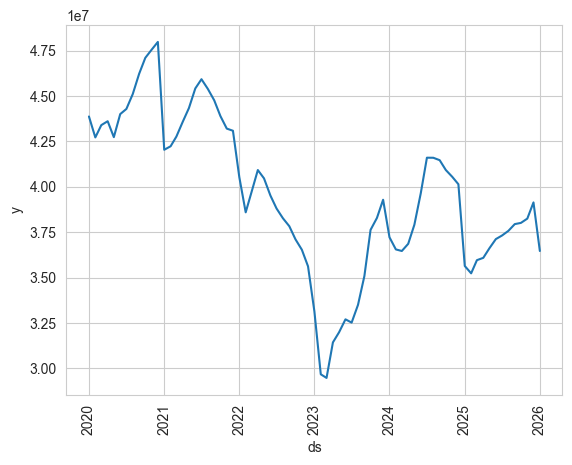

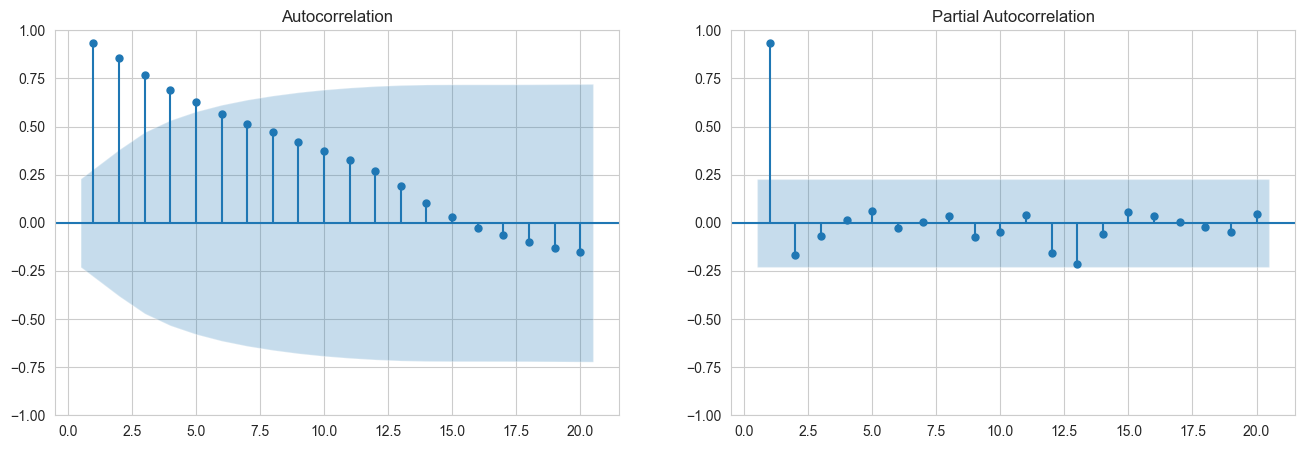

08:24:12 - cmdstanpy - INFO - Chain [1] start processing
08:24:13 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWa

Best params: (3, 0, 2) trend: ct


C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
D:\University\Диплом\simple_forecaster_tests\forecaster.py:360: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  exp_model = ExponentialSmoothing(endog = y_train['y'], seasonal_periods = seasonal_preiod, **study.best_params).fit()


,Test_MAE,Test_MAPE,Test_RMSE,Test_WAPE,Train_MAE,Train_MAPE,Train_RMSE,Train_WAPE
Model,,,,,,,,
prop,1.461568e+06,3.813182,1.617392e+06,3.850897,1.651792e+06,4.335148,1.960974e+06,4.170468
ar,2.333914e+06,6.214984,2.553372e+06,6.149329,6.196416e+05,1.611165,8.088183e+05,1.564480
exp,1.009652e+06,2.687670,1.153351e+06,2.660202,6.256422e+05,1.634149,8.183533e+05,1.579630
Ensemble,1.177574e+06,3.147873,1.410686e+06,3.102637,5.692080e+05,1.496197,7.566398e+05,1.437145


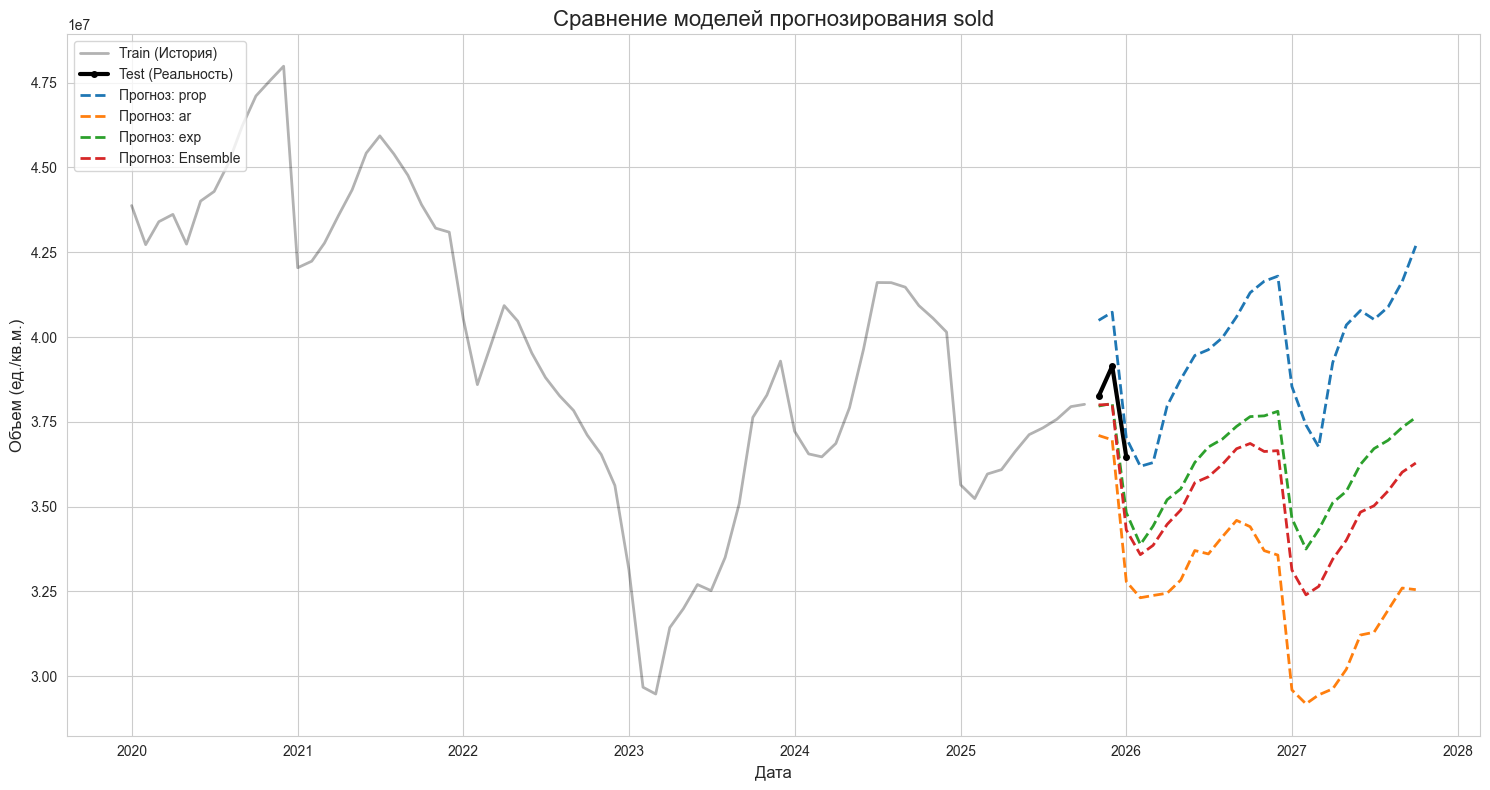

In [118]:
df['unsold/sold'] = df['unsold']/df['sold']
y = df[['Дата', 'sold']]
pred_stat, stat_df = multi_model_forecast(y, 24, test_size = 0.05, seasonal_preiod = 12, freq = 'MS', value_name = 'sold')

In [90]:
attrs = [a for a in dir(pred_stat['ar']['model']) if not a.startswith('_')]
print(attrs)

['forecast', 'get_prediction', 'model', 'model_result', 'period', 'result', 'stl', 'summary']


In [91]:
print(pred_stat['ar']['model'].model_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   70
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 149.668
Date:                Tue, 14 Apr 2026   AIC                           -285.336
Time:                        08:15:32   BIC                           -269.596
Sample:                             0   HQIC                          -279.084
                                 - 70                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6114      0.060     10.190      0.000       0.494       0.729
x1             0.0133      0.002      7.686      0.000       0.010       0.017
ar.L1          1.8775      0.091     20.592      0.0

In [95]:
train_data = pd.DataFrame()

In [96]:
train_data['arima'] = pred_stat['ar']['train_pred']
train_data['ES'] = pred_stat['exp']['train_pred']
train_data['prop'] = pred_stat['prop']['train_pred']
train_data = train_data.reset_index()
train_data['Исходный ряд'] = df['unsold/sold'][:-int(len(df['unsold/sold'])*0.05)].reset_index(drop = True)

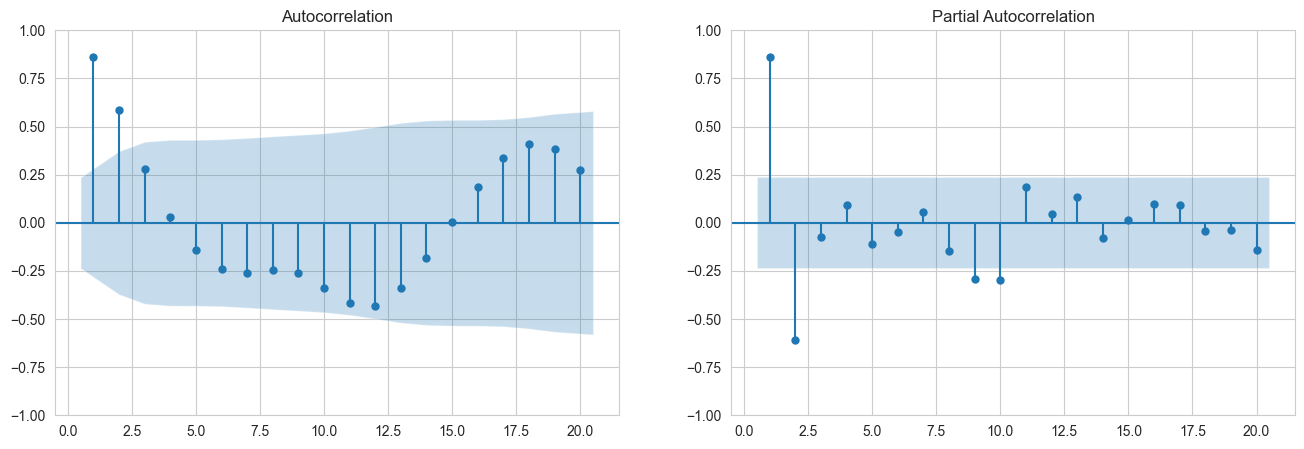

In [97]:
from statsmodels.tsa.seasonal import STL
res = STL(df['unsold/sold'][:-int(len(df['unsold/sold'])*0.05)][1:], period=12).fit()
acf_chacf(res.resid)

In [98]:
train_data

,ds,arima,ES,prop,Исходный ряд
0,2020-01-01,0.663081,0.848770,0.695298,0.848779
1,2020-02-01,0.853788,0.834964,0.728100,0.833236
2,2020-03-01,0.793009,0.796206,0.688658,0.799123
3,2020-04-01,0.783862,0.767249,0.686850,0.779121
4,2020-05-01,0.768887,0.760739,0.682364,0.770528
...,...,...,...,...,...
65,2025-06-01,1.437029,1.434029,1.489938,1.452808
66,2025-07-01,1.455558,1.460059,1.494048,1.463274
67,2025-08-01,1.465345,1.457981,1.495247,1.457842
68,2025-09-01,1.450641,1.446528,1.495171,1.446827


In [99]:
train_data_melt = train_data.reset_index(drop = True).melt(id_vars = 'ds')

In [100]:
train_data_melt

,ds,variable,value
0,2020-01-01,arima,0.663081
1,2020-02-01,arima,0.853788
2,2020-03-01,arima,0.793009
3,2020-04-01,arima,0.783862
4,2020-05-01,arima,0.768887
...,...,...,...
275,2025-06-01,Исходный ряд,1.452808
276,2025-07-01,Исходный ряд,1.463274
277,2025-08-01,Исходный ряд,1.457842
278,2025-09-01,Исходный ряд,1.446827


C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

<Axes: xlabel='ds', ylabel='value'>

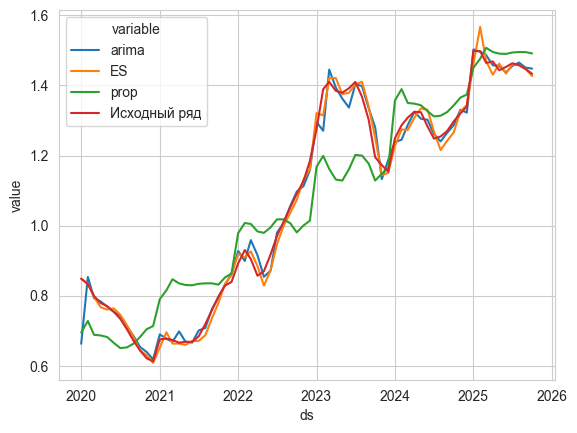

In [101]:
sns.lineplot(train_data_melt, x = 'ds', y = 'value',  hue = 'variable')

C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='ds', ylabel='value'>

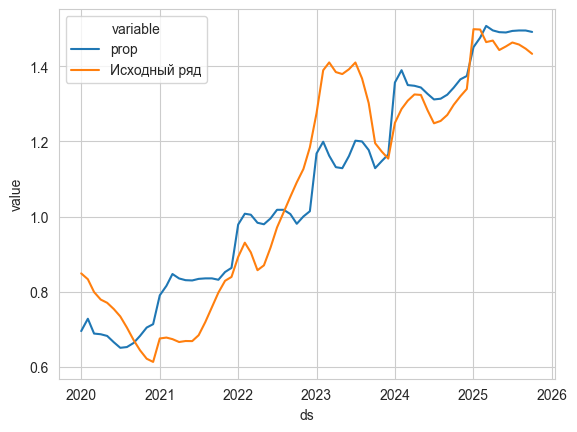

In [113]:
sns.lineplot(train_data_melt[train_data_melt['variable'].isin(['prop', 'Исходный ряд'])], x = 'ds', y = 'value',  hue = 'variable')

In [114]:
prop_res = train_data['Исходный ряд'] - train_data['prop']

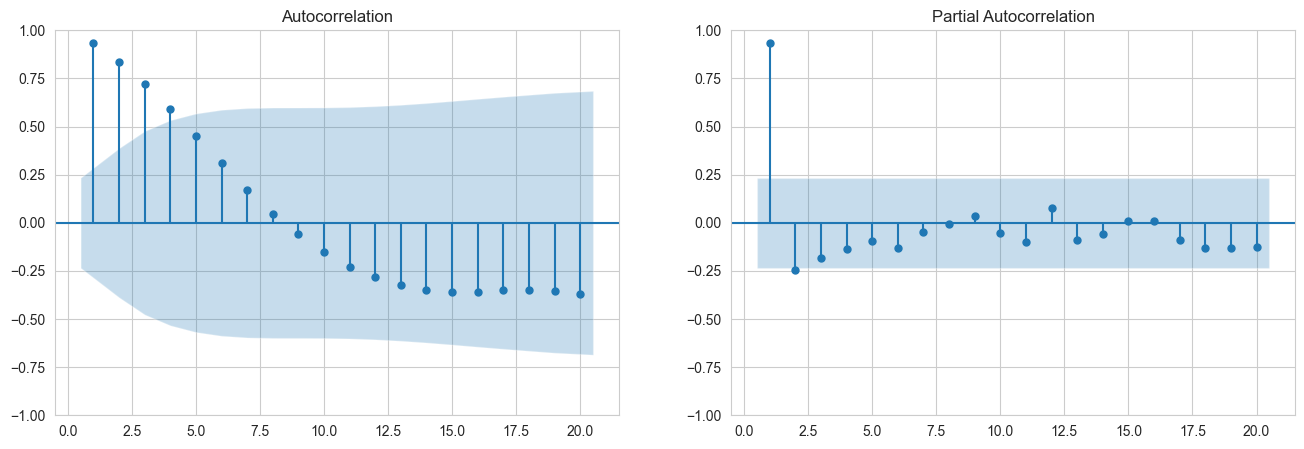

In [115]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
def acf_chacf(sr):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # ACF
    plot_acf(sr, lags=20, ax=axes[0], zero=False)
    # PACF
    plot_pacf(sr, lags=20, ax=axes[1], method='ywm', zero=False)
    
    plt.show()
    
acf_chacf(prop_res)

In [116]:
import statsmodels.api as sm
sm.stats.acorr_ljungbox(prop_res, lags=[20], return_df=True)

,lb_stat,lb_pvalue
20,313.911571,1.155236e-54


D:\University\Диплом\simple_forecaster_tests\forecaster.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result.loc['Исходный ряд', 'KPSS'] = kpss(series)[1]


                  ADF  KPSS        PP
Исходный ряд  0.97834  0.01  0.989903


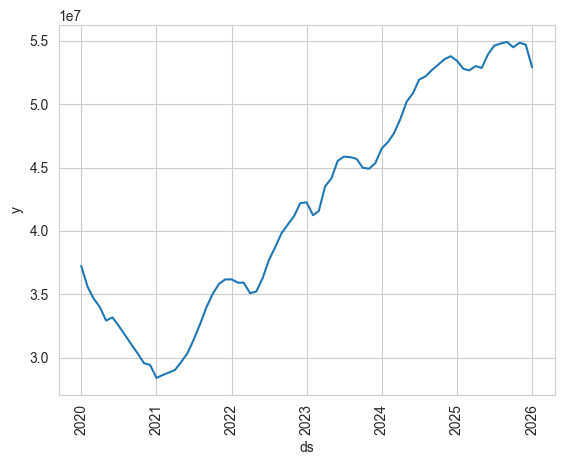

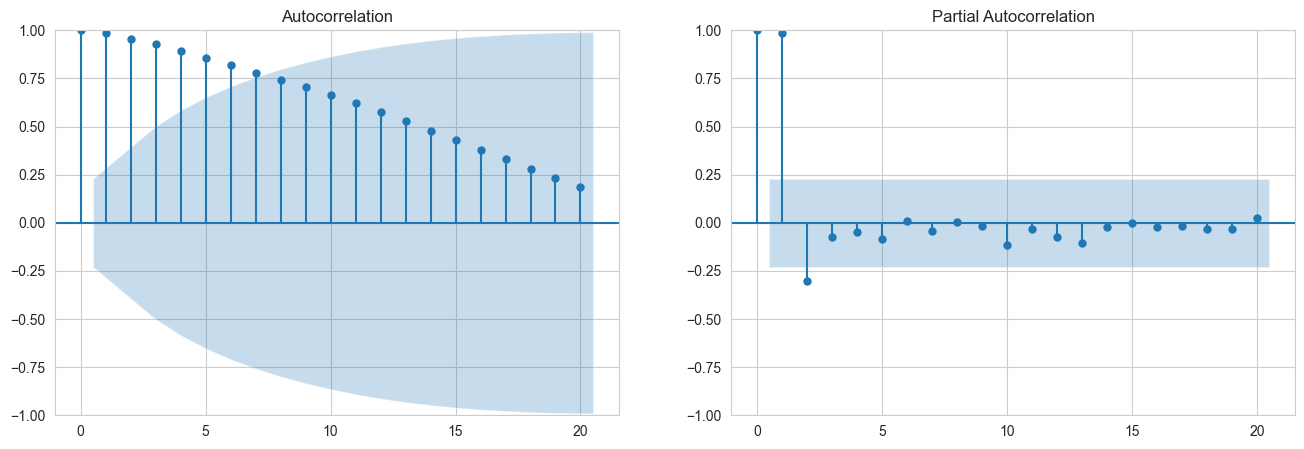

07:40:51 - cmdstanpy - INFO - Chain [1] start processing
07:40:53 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nikit\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\ts

Best params: (2, 0, 0) trend: ct


D:\University\Диплом\simple_forecaster_tests\forecaster.py:360: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  exp_model = ExponentialSmoothing(endog = y_train['y'], seasonal_periods = seasonal_preiod, **study.best_params).fit()


,Test_MAE,Test_MAPE,Test_RMSE,Test_WAPE,Train_MAE,Train_MAPE,Train_RMSE,Train_WAPE
Model,,,,,,,,
prop,3.324137e+06,6.157415,3.870982e+06,6.175208,685471.609897,1.766865,8.350237e+05,1.749000
ar,1.786152e+06,3.312756,2.033715e+06,3.318112,684658.858345,1.923737,1.236681e+06,1.746927
exp,4.119748e+06,7.625320,4.762980e+06,7.653204,404784.470617,1.062322,5.379526e+05,1.032819
Ensemble,3.227796e+06,5.976979,3.751494e+06,5.996236,350108.510453,0.951232,5.036041e+05,0.893312


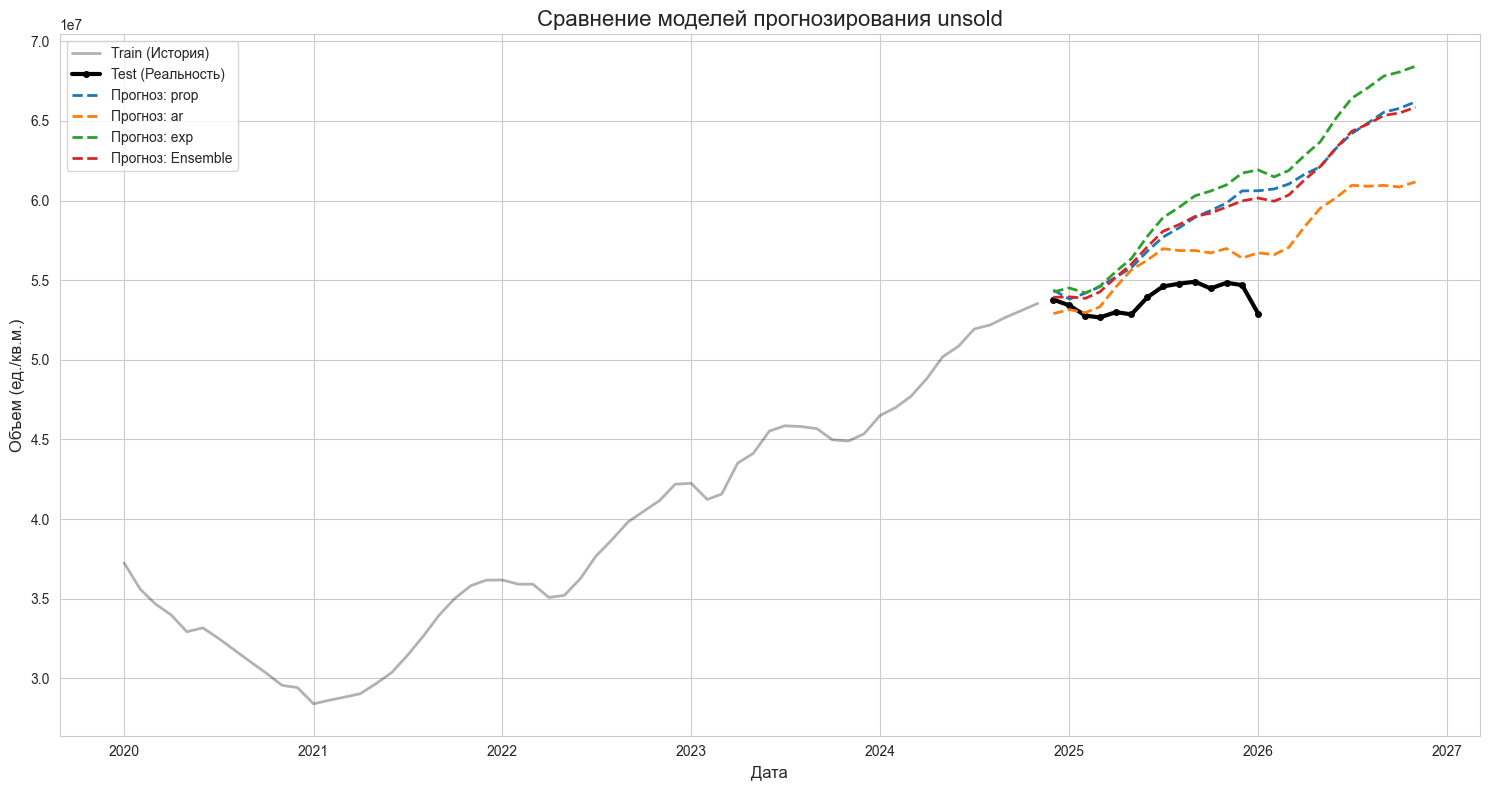

In [17]:
y = df[['Дата', 'unsold']]
pred_stat, stat_df = multi_model_forecast(y, 24, test_size = 0.2, seasonal_preiod = 12, freq = 'MS', value_name = 'unsold')

D:\University\Диплом\simple_forecaster_tests\forecaster.py:152: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result.loc['Исходный ряд', 'KPSS'] = kpss(series)[1]


                   ADF  KPSS        PP
Исходный ряд  0.821263  0.01  0.848129


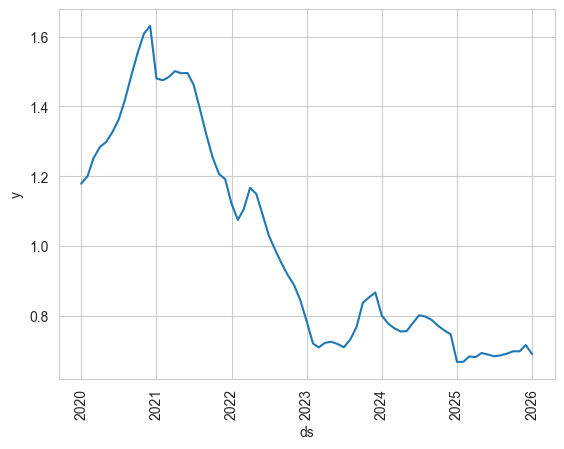

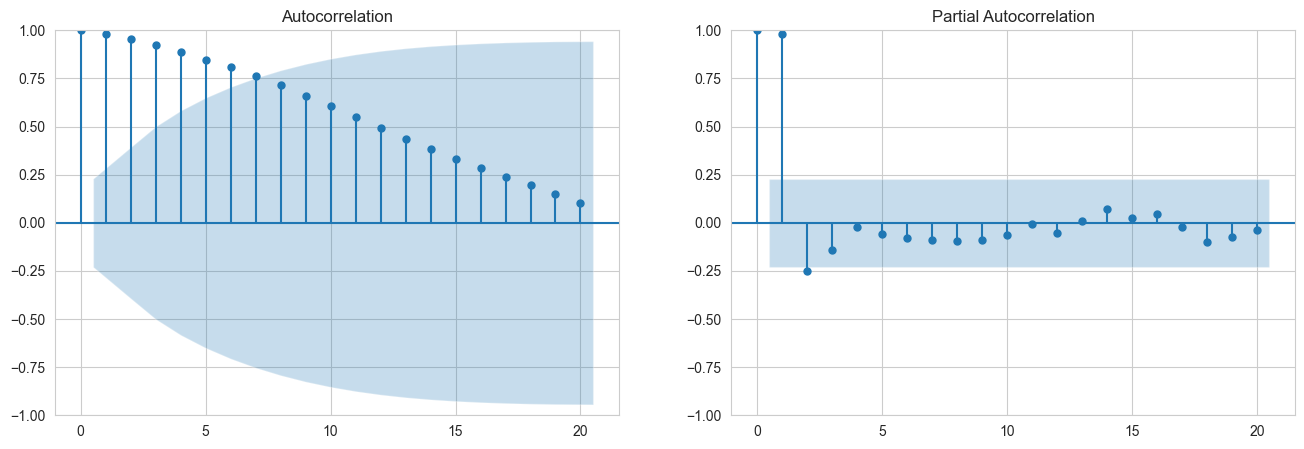

12:51:31 - cmdstanpy - INFO - Chain [1] start processing
12:51:31 - cmdstanpy - INFO - Chain [1] done processing
D:\University\Диплом\simple_forecaster_tests\forecaster.py:346: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  exp_model = ExponentialSmoothing(endog = y_train['y'], seasonal_periods = seasonal_preiod, **study.best_params).fit()


,Test_MAE,Test_MAPE,Test_RMSE,Test_WAPE,Train_MAE,Train_MAPE,Train_RMSE,Train_WAPE
Model,,,,,,,,
prop,0.181561,26.227871,0.190220,26.238720,0.118259,11.617957,0.136947,11.011938
ar,0.022743,3.273085,0.027277,3.286791,0.037686,3.443830,0.166483,3.509185
exp,0.018218,2.637533,0.021733,2.632840,0.018439,1.804656,0.023338,1.716949
Ensemble,0.023291,3.377872,0.026638,3.365960,0.023415,2.244852,0.050878,2.180381


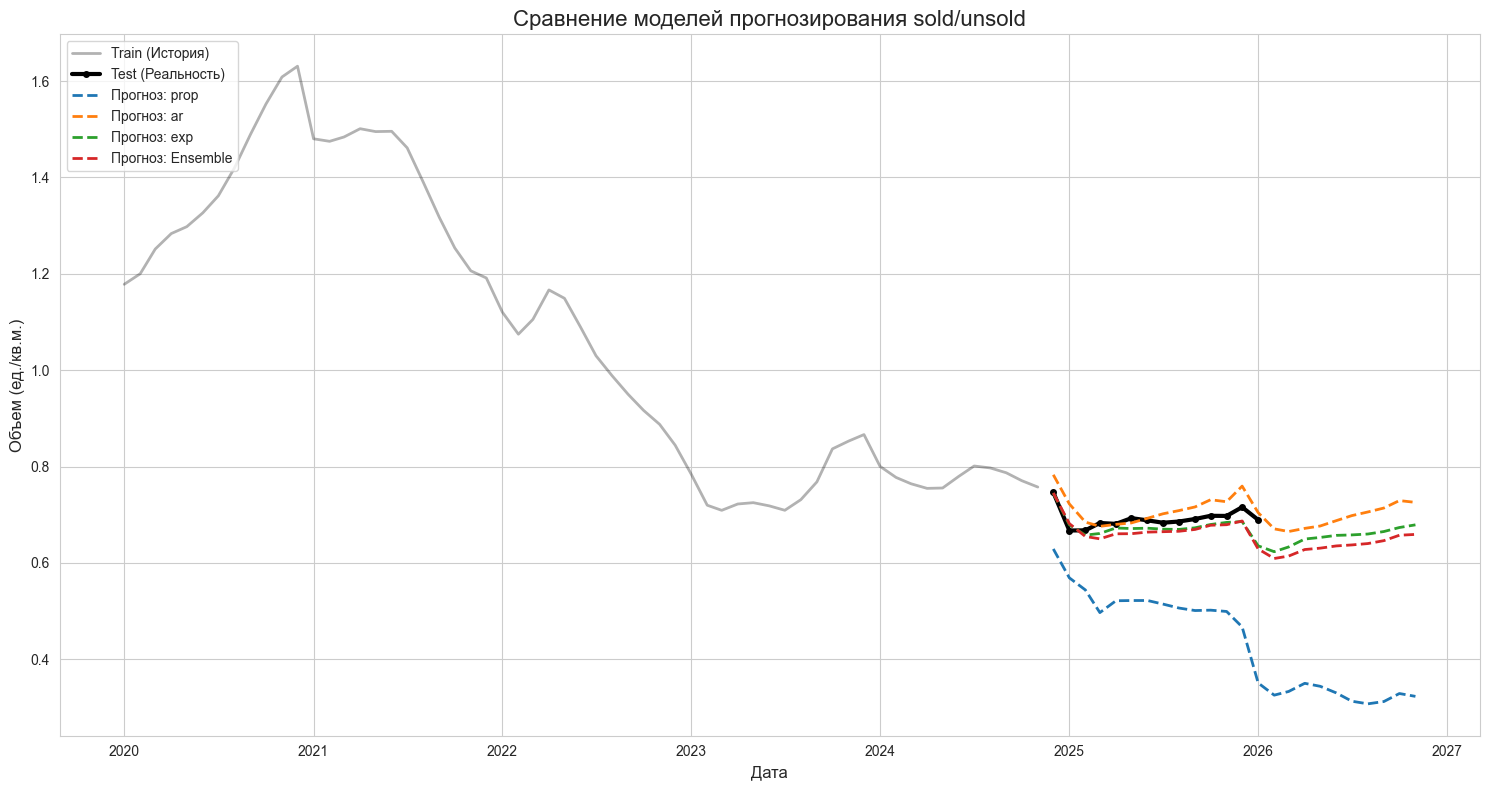

In [7]:
df['sold/unsold'] = df['sold']/df['unsold']
y = df[['Дата', 'sold/unsold']]
pred_stat, stat_df = multi_model_forecast(y, 24, test_size = 0.2, seasonal_preiod = 12, freq = 'MS', value_name = 'sold/unsold')

In [8]:
pred_stat['Ensemble']['weights']

{'prop': 0.09477147742380473,
 'ar': 0.29739601333432736,
 'exp': 0.6078325092418678}